<a href="https://www.kaggle.com/code/abreton5330/medicaid-expenditure-projection-project?scriptVersionId=322362427" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Medicaid Expenditure Projection Model

**Project goal:** Build a data-driven forecasting notebook that analyzes historical Medicaid expenditure data and projects expenditures for **2026-2035** for a selected state and for the national total.

This notebook is designed to run on **Kaggle**. It automatically searches `/kaggle/input` for the uploaded Excel files.

## Assignment checklist covered in this notebook

- Ingest and clean historical Excel files
- Perform EDA: historical trends, year-over-year growth, decomposition
- Build and evaluate multiple models: Linear Regression, Polynomial Regression, Exponential Smoothing, ARIMA
- Compare models using MAE, RMSE, and MAPE
- Select the best model for each series
- Produce 10-year forecasts for 2026-2035
- Include 95% confidence intervals
- Visualize historical and forecasted expenditures
- Export forecast tables, model comparison, charts, HTML report, PDF report, and README

## 1. Setup

Change `STATE` below if your instructor wants a different state. The rest of the notebook will run automatically.

In [1]:
STATE = "NEW YORK"   # Change this if needed, for example: "NEW JERSEY", "TEXAS", "CALIFORNIA"
FORECAST_START_YEAR = 2026
FORECAST_END_YEAR = 2035
TEST_SIZE = 3

In [2]:
# ============================================================
# PATCH 1 — Suppress ARIMA convergence warnings
# Place near imports section
# ============================================================

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

from pathlib import Path
import re
import os
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

from matplotlib.backends.backend_pdf import PdfPages

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (11, 6)

## 2. Locate and load the Excel files

Kaggle stores uploaded datasets inside `/kaggle/input`. This cell searches all folders inside that location and finds files named like `FY_2013_MFCU_Statistical_Chart.xlsx`.

In [3]:
# Existing search root logic
search_root = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path(".")

# Dataset 1: MFCU Statistical Excel files
files = sorted(search_root.rglob("FY_*_MFCU_Statistical_Chart.xlsx"))

print(f"Search root: {search_root}")
print(f"Excel files found: {len(files)}")
for file in files:
    print(file)

if len(files) == 0:
    raise FileNotFoundError(
        "No Excel files were found. In Kaggle, use Add Data to attach the dataset containing the FY Excel files."
    )

# Dataset 2: NYS Medicaid Enrollment Databook CSV
enrollment_files = sorted(search_root.rglob("nys_medicaid_enrollment_databook_raw.csv"))

print(f"\nEnrollment CSV files found: {len(enrollment_files)}")
for file in enrollment_files:
    print(file)

if len(enrollment_files) == 0:
    raise FileNotFoundError(
        "No enrollment CSV file was found. In Kaggle, use Add Data to attach the dataset containing nys_medicaid_enrollment_databook_raw.csv."
    )

enrollment_file = enrollment_files[0]

print(f"\nSelected enrollment file: {enrollment_file}")

Search root: /kaggle/input
Excel files found: 13
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2013_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2014_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2015_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2016_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2017_MFCU_Statistical_Chart.xlsx
/kaggle/input/datasets/abreton5330/medicaid-expenditure-projection-model-project/Medicaid Expenditure Projection Model Project/FY_2018_M

## 3. Data cleaning functions

The files do not use perfectly identical column names every year. For example, some years use `State`, others use `State1`, and Medicaid expenditure columns may have footnote numbers. These helper functions make the cleaning process reliable.

In [4]:
def extract_fiscal_year(file_path):
    """Extract fiscal year from a filename like FY_2025_MFCU_Statistical_Chart.xlsx."""
    match = re.search(r"FY_(\d{4})", file_path.name)
    if not match:
        raise ValueError(f"Could not extract fiscal year from {file_path.name}")
    return int(match.group(1))


def find_state_column(columns):
    """Find the state column, allowing names like State or State1."""
    for col in columns:
        cleaned = re.sub(r"\d+$", "", str(col)).strip().lower()
        if cleaned == "state":
            return col
    raise ValueError(f"Could not find a State column. Columns found: {list(columns)}")


def find_expenditure_column(columns):
    """Find the total Medicaid expenditure column, allowing footnote numbers."""
    candidates = [col for col in columns if "total medicaid expenditures" in str(col).lower()]
    if not candidates:
        raise ValueError(f"Could not find Medicaid expenditure column. Columns found: {list(columns)}")
    return candidates[0]


def clean_state_name(value):
    """Standardize state names and national total row names."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = value.replace(":", "")
    value = re.sub(r"\s+", " ", value)
    upper = value.upper()
    if upper in ["TOTAL", "GRAND TOTAL", "TOTALS"] or upper.startswith("TOTAL") or upper.startswith("GRAND TOTAL"):
        return "TOTAL"
    return upper


def to_number(series):
    """Convert currency-like values to numeric."""
    return pd.to_numeric(
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [5]:
all_data = []
load_log = []

for file in files:
    year = extract_fiscal_year(file)
    raw = pd.read_excel(file, header=1)
    raw.columns = raw.columns.astype(str).str.strip()
    
    state_col = find_state_column(raw.columns)
    expenditure_col = find_expenditure_column(raw.columns)
    
    temp = pd.DataFrame({
        "Fiscal Year": year,
        "State_raw": raw[state_col],
        "State": raw[state_col].apply(clean_state_name),
        "Expenditures": to_number(raw[expenditure_col]),
        "Source File": file.name
    })
    
    # Keep state rows and national total rows that have actual expenditure values.
    temp = temp.dropna(subset=["State", "Expenditures"])
    
    all_data.append(temp)
    load_log.append({
        "Fiscal Year": year,
        "Rows Loaded": len(temp),
        "State Column": state_col,
        "Expenditure Column": expenditure_col,
        "File": file.name
    })

medicaid = pd.concat(all_data, ignore_index=True)
load_log = pd.DataFrame(load_log).sort_values("Fiscal Year")

print("Combined data shape:", medicaid.shape)
display(load_log)
display(medicaid.head())

Combined data shape: (683, 5)


,Fiscal Year,Rows Loaded,State Column,Expenditure Column,File
0,2013,51,State,Total Medicaid Expenditures,FY_2013_MFCU_Statistical_Chart.xlsx
1,2014,51,State,Total Medicaid Expenditures,FY_2014_MFCU_Statistical_Chart.xlsx
2,2015,51,State,Total Medicaid Expenditures3,FY_2015_MFCU_Statistical_Chart.xlsx
3,2016,51,State,Total Medicaid Expenditures3,FY_2016_MFCU_Statistical_Chart.xlsx
4,2017,51,State,Total Medicaid Expenditures3,FY_2017_MFCU_Statistical_Chart.xlsx
5,2018,51,State,Total Medicaid Expenditures3,FY_2018_MFCU_Statistical_Chart.xlsx
6,2019,53,State1,Total Medicaid Expenditures4,FY_2019_MFCU_Statistical_Chart.xlsx
7,2020,54,State,Total Medicaid Expenditures3,FY_2020_MFCU_Statistical_Chart.xlsx
8,2021,54,State,Total Medicaid Expenditures3,FY_2021_MFCU_Statistical_Chart.xlsx
9,2022,54,State,Total Medicaid Expenditures3,FY_2022_MFCU_Statistical_Chart.xlsx


,Fiscal Year,State_raw,State,Expenditures,Source File
0,2013,Alabama,ALABAMA,"5,216,155,508.00",FY_2013_MFCU_Statistical_Chart.xlsx
1,2013,Alaska,ALASKA,"1,446,189,444.00",FY_2013_MFCU_Statistical_Chart.xlsx
2,2013,Arizona,ARIZONA,"8,669,976,278.00",FY_2013_MFCU_Statistical_Chart.xlsx
3,2013,Arkansas,ARKANSAS,"4,428,390,909.00",FY_2013_MFCU_Statistical_Chart.xlsx
4,2013,California,CALIFORNIA,"66,056,757,855.00",FY_2013_MFCU_Statistical_Chart.xlsx


## 4. Validate the cleaned data

This step checks whether the selected state and the national total are present across the expected fiscal years.

In [6]:
available_states = sorted(medicaid["State"].dropna().unique())
print(f"Number of unique State labels: {len(available_states)}")
print("Selected state:", STATE.upper())

if STATE.upper() not in available_states:
    print("Selected state was not found. Here are matching or nearby state labels:")
    matches = [s for s in available_states if STATE.split()[0].upper() in s]
    print(matches[:20])
    raise ValueError("Please update STATE at the top of the notebook to match one of the available state names.")

state_df = medicaid[medicaid["State"] == STATE.upper()].copy()
national_df = medicaid[medicaid["State"] == "TOTAL"].copy()

state_df = state_df.sort_values("Fiscal Year")
national_df = national_df.sort_values("Fiscal Year")

print(f"{STATE.upper()} rows:", state_df.shape[0])
print("National TOTAL rows:", national_df.shape[0])

display(state_df[["Fiscal Year", "State", "Expenditures"]])
display(national_df[["Fiscal Year", "State", "Expenditures"]])

Number of unique State labels: 54
Selected state: NEW YORK
NEW YORK rows: 13
National TOTAL rows: 13


,Fiscal Year,State,Expenditures
32,2013,NEW YORK,"54,192,911,238.00"
83,2014,NEW YORK,"53,915,930,694.00"
134,2015,NEW YORK,"59,681,117,761.00"
185,2016,NEW YORK,"62,909,519,309.00"
236,2017,NEW YORK,"78,563,137,293.00"
287,2018,NEW YORK,"75,262,657,182.00"
338,2019,NEW YORK,"60,209,122,828.00"
391,2020,NEW YORK,"72,816,196,684.00"
445,2021,NEW YORK,"73,267,974,087.00"
499,2022,NEW YORK,"82,564,771,704.00"


,Fiscal Year,State,Expenditures
50,2013,TOTAL,"453,082,711,064.00"
101,2014,TOTAL,"488,240,409,971.00"
152,2015,TOTAL,"548,190,828,914.00"
203,2016,TOTAL,"571,229,555,606.00"
254,2017,TOTAL,"596,434,360,108.00"
305,2018,TOTAL,"611,976,826,895.00"
358,2019,TOTAL,"614,908,690,223.00"
412,2020,TOTAL,"678,892,781,237.00"
466,2021,TOTAL,"740,285,561,048.00"
520,2022,TOTAL,"823,865,414,079.00"


## 5. Exploratory Data Analysis

This section visualizes historical Medicaid expenditures and year-over-year growth for the selected state and the national total.

In [7]:
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working


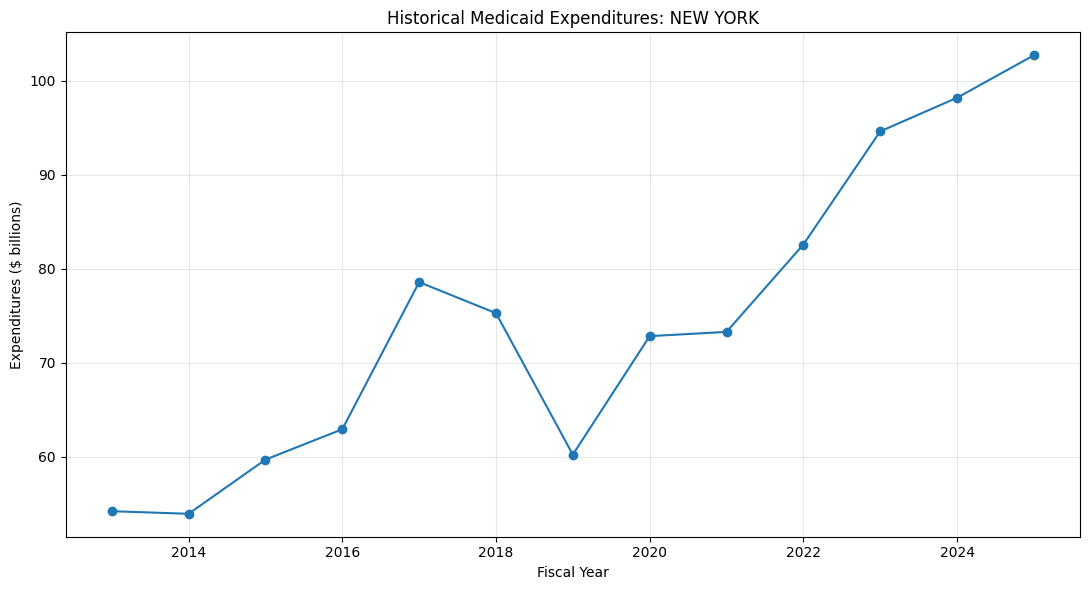

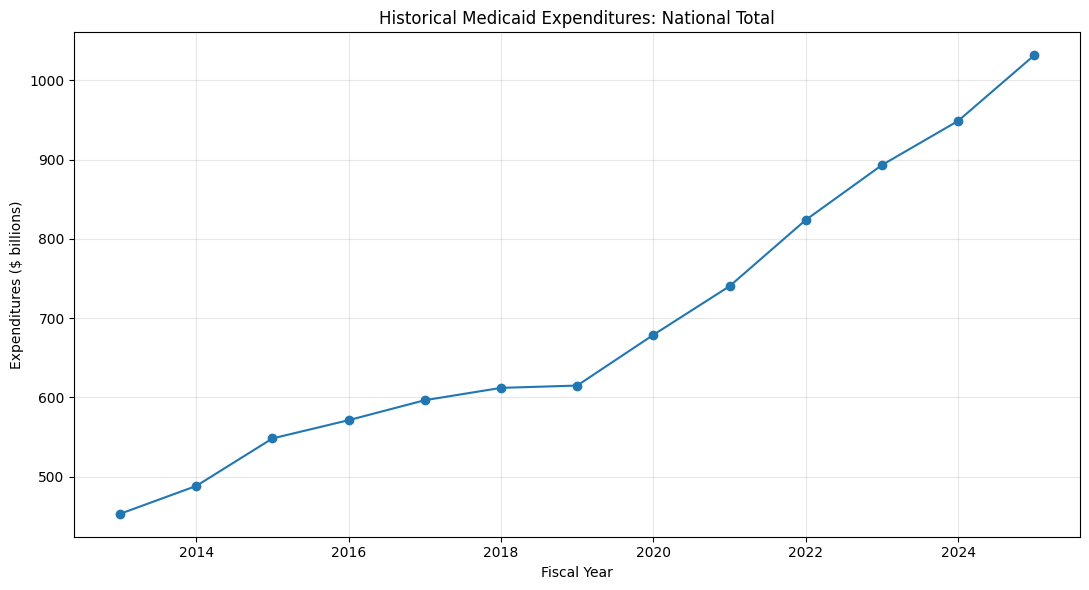

In [8]:
def dollars_billions(x):
    return x / 1_000_000_000


def plot_history(df, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(df["Fiscal Year"], dollars_billions(df["Expenditures"]), marker="o")
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_history_chart = plot_history(state_df, f"Historical Medicaid Expenditures: {STATE.upper()}", "state_historical_expenditures.png")
national_history_chart = plot_history(national_df, "Historical Medicaid Expenditures: National Total", "national_historical_expenditures.png")

In [9]:
def add_yoy_growth(df):
    out = df.copy().sort_values("Fiscal Year")
    out["YoY Growth %"] = out["Expenditures"].pct_change() * 100
    return out

state_eda = add_yoy_growth(state_df)
national_eda = add_yoy_growth(national_df)

display(state_eda[["Fiscal Year", "State", "Expenditures", "YoY Growth %"]])
display(national_eda[["Fiscal Year", "State", "Expenditures", "YoY Growth %"]])

,Fiscal Year,State,Expenditures,YoY Growth %
32,2013,NEW YORK,"54,192,911,238.00",NaN
83,2014,NEW YORK,"53,915,930,694.00",-0.51
134,2015,NEW YORK,"59,681,117,761.00",10.69
185,2016,NEW YORK,"62,909,519,309.00",5.41
236,2017,NEW YORK,"78,563,137,293.00",24.88
287,2018,NEW YORK,"75,262,657,182.00",-4.20
338,2019,NEW YORK,"60,209,122,828.00",-20.00
391,2020,NEW YORK,"72,816,196,684.00",20.94
445,2021,NEW YORK,"73,267,974,087.00",0.62
499,2022,NEW YORK,"82,564,771,704.00",12.69


,Fiscal Year,State,Expenditures,YoY Growth %
50,2013,TOTAL,"453,082,711,064.00",NaN
101,2014,TOTAL,"488,240,409,971.00",7.76
152,2015,TOTAL,"548,190,828,914.00",12.28
203,2016,TOTAL,"571,229,555,606.00",4.20
254,2017,TOTAL,"596,434,360,108.00",4.41
305,2018,TOTAL,"611,976,826,895.00",2.61
358,2019,TOTAL,"614,908,690,223.00",0.48
412,2020,TOTAL,"678,892,781,237.00",10.41
466,2021,TOTAL,"740,285,561,048.00",9.04
520,2022,TOTAL,"823,865,414,079.00",11.29


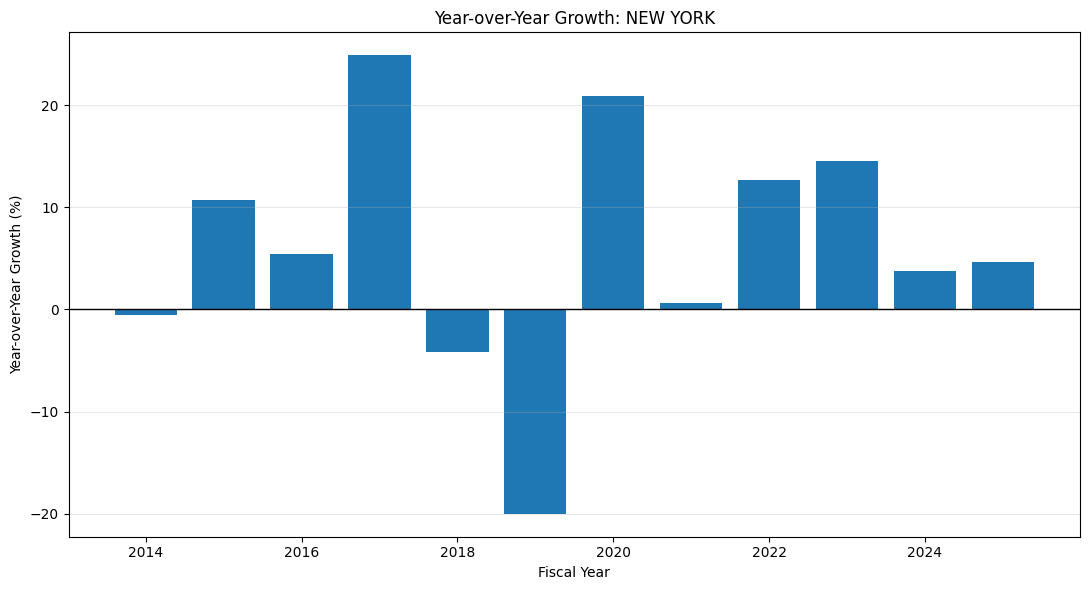

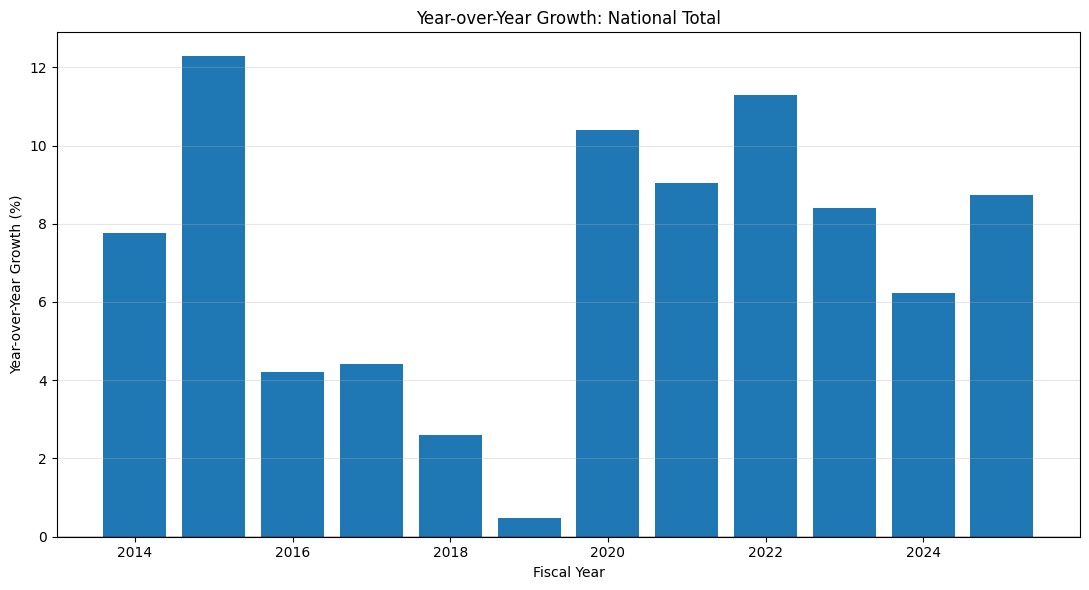

In [10]:
def plot_growth(df, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    growth_df = df.dropna(subset=["YoY Growth %"])
    ax.bar(growth_df["Fiscal Year"], growth_df["YoY Growth %"])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Year-over-Year Growth (%)")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_growth_chart = plot_growth(state_eda, f"Year-over-Year Growth: {STATE.upper()}", "state_yoy_growth.png")
national_growth_chart = plot_growth(national_eda, "Year-over-Year Growth: National Total", "national_yoy_growth.png")

## 6. Time-series decomposition

The dataset is annual, so seasonality is limited. The decomposition below is included as a diagnostic view of trend, seasonal-like movement, and residuals. A short period of 3 is used because there are only 13 annual observations.

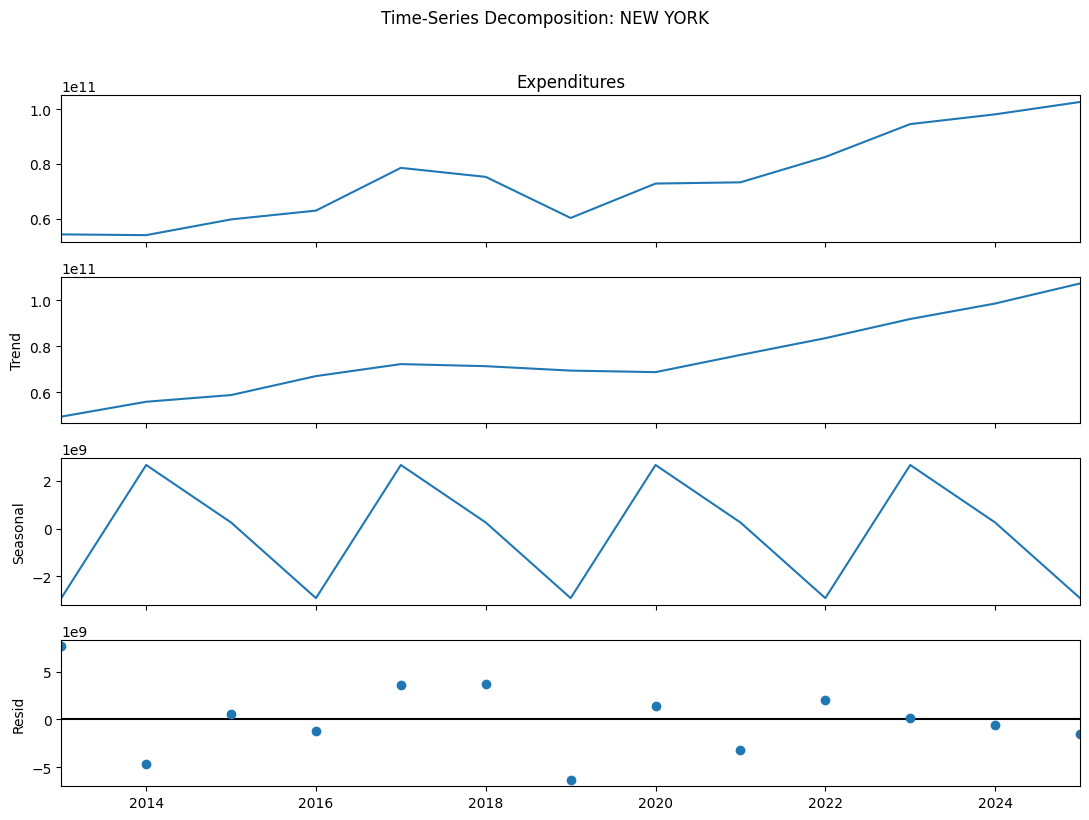

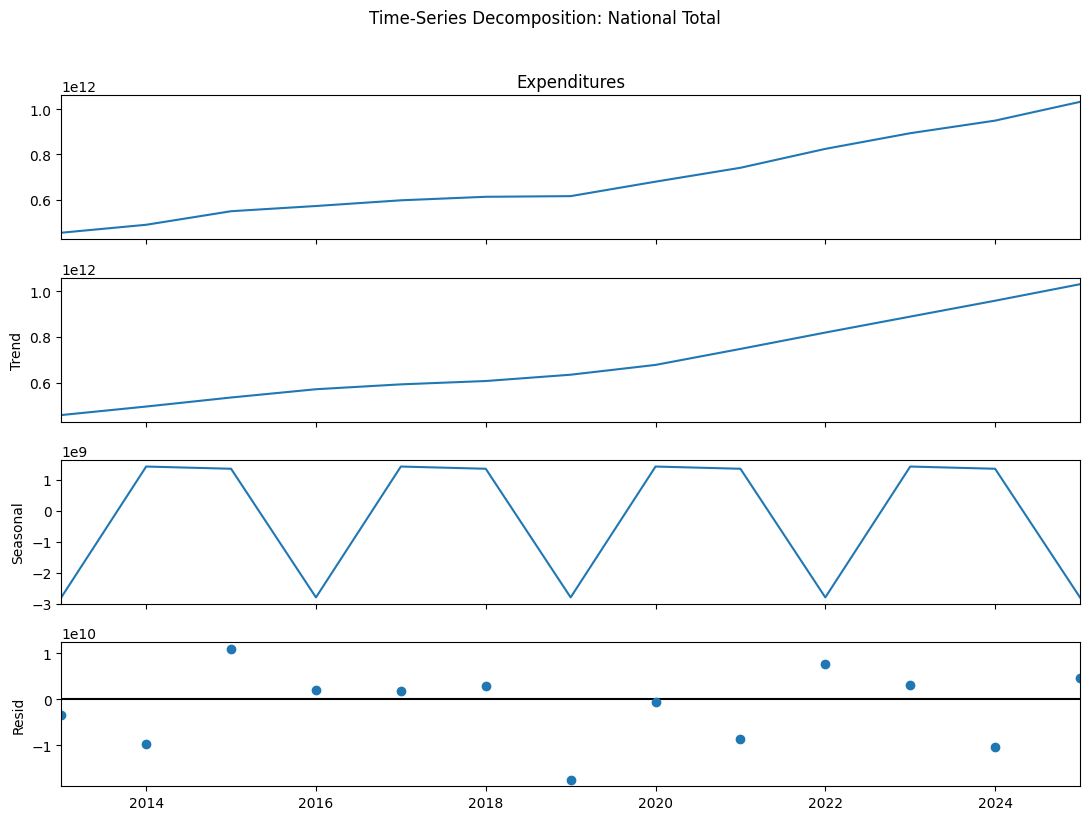

In [11]:
def plot_decomposition(df, title, filename, period=3):
    series = df.sort_values("Fiscal Year").set_index("Fiscal Year")["Expenditures"]
    if len(series) < period * 2:
        print(f"Not enough data for decomposition: {title}")
        return None
    
    decomposition = seasonal_decompose(series, model="additive", period=period, extrapolate_trend="freq")
    fig = decomposition.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_decomp_chart = plot_decomposition(state_df, f"Time-Series Decomposition: {STATE.upper()}", "state_decomposition.png")
national_decomp_chart = plot_decomposition(national_df, "Time-Series Decomposition: National Total", "national_decomposition.png")

## 7. Modeling helper functions

We evaluate several forecasting models on the last 3 historical years:

1. Linear Regression
2. Polynomial Regression
3. Exponential Smoothing
4. ARIMA

Metrics used:

- **MAE:** Mean Absolute Error
- **RMSE:** Root Mean Squared Error
- **MAPE:** Mean Absolute Percentage Error

In [12]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    nonzero = actual != 0
    mape = np.mean(np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])) * 100
    return mae, rmse, mape


def evaluate_models(df, entity_name, test_size=3):
    series_df = df.sort_values("Fiscal Year").dropna(subset=["Expenditures"]).copy()
    if len(series_df) <= test_size + 2:
        raise ValueError(f"Not enough observations to evaluate models for {entity_name}.")
    
    train = series_df.iloc[:-test_size].copy()
    test = series_df.iloc[-test_size:].copy()
    
    X_train = train[["Fiscal Year"]]
    y_train = train["Expenditures"]
    X_test = test[["Fiscal Year"]]
    y_test = test["Expenditures"]
    
    results = []
    predictions_by_model = {}
    model_info = {}
    
    # 1. Linear Regression
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    pred = linear_model.predict(X_test)
    mae, rmse, mape = calculate_metrics(y_test, pred)
    results.append({"Entity": entity_name, "Model": "Linear Regression", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    predictions_by_model["Linear Regression"] = pred
    model_info["Linear Regression"] = {"model": linear_model}
    
    # 2. Polynomial Regression Degree 2
    poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    poly_model.fit(X_train, y_train)
    pred = poly_model.predict(X_test)
    mae, rmse, mape = calculate_metrics(y_test, pred)
    results.append({"Entity": entity_name, "Model": "Polynomial Regression", "MAE": mae, "RMSE": rmse, "MAPE": mape})
    predictions_by_model["Polynomial Regression"] = pred
    model_info["Polynomial Regression"] = {"model": poly_model}
    
    # 3. Exponential Smoothing
    try:
        ets_model = ExponentialSmoothing(y_train.values, trend="add", seasonal=None, initialization_method="estimated")
        ets_fit = ets_model.fit(optimized=True)
        pred = ets_fit.forecast(len(test))
        mae, rmse, mape = calculate_metrics(y_test, pred)
        results.append({"Entity": entity_name, "Model": "Exponential Smoothing", "MAE": mae, "RMSE": rmse, "MAPE": mape})
        predictions_by_model["Exponential Smoothing"] = pred
        model_info["Exponential Smoothing"] = {"model": ets_fit}
    except Exception as e:
        print(f"Exponential Smoothing failed for {entity_name}: {e}")
    
    # 4. ARIMA candidates
    arima_orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0), (0, 2, 1)]
    best_arima = None
    for order in arima_orders:
        try:
            arima_fit = ARIMA(y_train.values, order=order).fit()
            pred = arima_fit.forecast(steps=len(test))
            mae, rmse, mape = calculate_metrics(y_test, pred)
            row = {"Entity": entity_name, "Model": f"ARIMA{order}", "MAE": mae, "RMSE": rmse, "MAPE": mape}
            if best_arima is None or row["MAPE"] < best_arima["MAPE"]:
                best_arima = {**row, "order": order, "fit": arima_fit, "pred": pred}
        except Exception:
            pass
    
    if best_arima is not None:
        results.append({k: best_arima[k] for k in ["Entity", "Model", "MAE", "RMSE", "MAPE"]})
        predictions_by_model[best_arima["Model"]] = best_arima["pred"]
        model_info[best_arima["Model"]] = {"order": best_arima["order"], "model": best_arima["fit"]}
    
    comparison = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
    best_model_name = comparison.loc[0, "Model"]
    
    return comparison, best_model_name, train, test, predictions_by_model, model_info

## 8. Evaluate models for the selected state

In [13]:
state_comparison, state_best_model, state_train, state_test, state_test_predictions, state_model_info = evaluate_models(
    state_df, STATE.upper(), TEST_SIZE
)

print("Best state model:", state_best_model)
display(state_comparison)

Best state model: ARIMA(0, 2, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Entity,Model,MAE,RMSE,MAPE
0,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,825.52","5,871,513,803.78",5.93
1,NEW YORK,Linear Regression,"13,620,957,151.70","13,667,389,832.96",13.81
2,NEW YORK,Exponential Smoothing,"13,620,957,151.72","13,667,389,832.98",13.81
3,NEW YORK,Polynomial Regression,"19,167,953,620.50","19,373,935,444.26",19.39


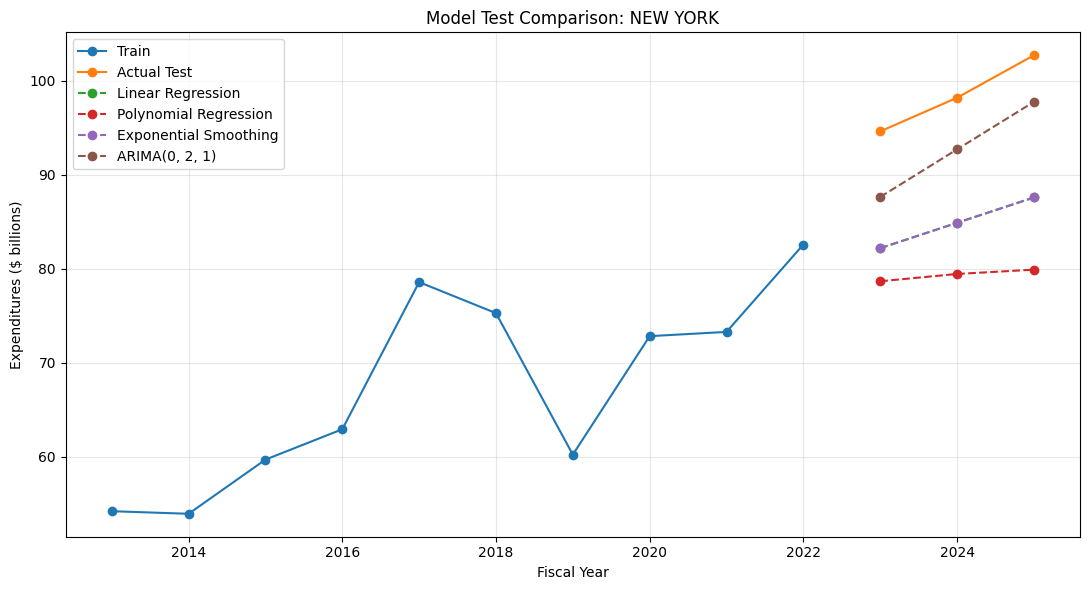

In [14]:
def plot_test_predictions(train, test, predictions_by_model, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(train["Fiscal Year"], dollars_billions(train["Expenditures"]), marker="o", label="Train")
    ax.plot(test["Fiscal Year"], dollars_billions(test["Expenditures"]), marker="o", label="Actual Test")
    
    for model_name, preds in predictions_by_model.items():
        ax.plot(test["Fiscal Year"], dollars_billions(np.asarray(preds)), marker="o", linestyle="--", label=model_name)
    
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_test_chart = plot_test_predictions(
    state_train, state_test, state_test_predictions,
    f"Model Test Comparison: {STATE.upper()}",
    "state_model_test_comparison.png"
)

## 9. Evaluate models for the national total

In [15]:
national_comparison, national_best_model, national_train, national_test, national_test_predictions, national_model_info = evaluate_models(
    national_df, "NATIONAL TOTAL", TEST_SIZE
)

print("Best national model:", national_best_model)
display(national_comparison)

Best national model: Exponential Smoothing


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,504,840.23","29,144,348,877.18",2.74
1,NATIONAL TOTAL,"ARIMA(0, 2, 1)","30,389,179,091.86","32,801,601,321.16",3.12
2,NATIONAL TOTAL,Polynomial Regression,"47,102,709,321.58","47,978,768,884.15",4.89
3,NATIONAL TOTAL,Linear Regression,"112,706,434,239.57","116,157,169,999.72",11.64


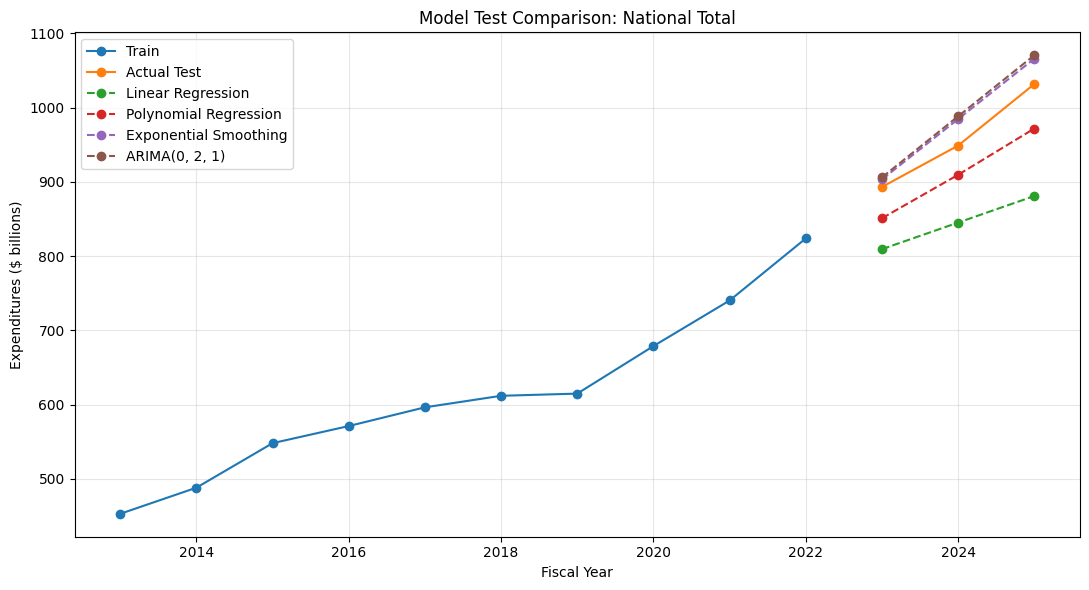

In [16]:
national_test_chart = plot_test_predictions(
    national_train, national_test, national_test_predictions,
    "Model Test Comparison: National Total",
    "national_model_test_comparison.png"
)

## 10. Final forecast functions

The best model by MAPE is refit on all available historical data. The notebook then forecasts 2026-2035 and adds approximate 95% confidence intervals.

For regression and exponential smoothing models, confidence intervals use historical residual variation. For ARIMA models, confidence intervals come from the ARIMA forecast object when available.

In [17]:
def forecast_with_best_model(df, entity_name, best_model_name, forecast_start=2026, forecast_end=2035):
    full = df.sort_values("Fiscal Year").dropna(subset=["Expenditures"]).copy()
    future_years = pd.DataFrame({"Fiscal Year": range(forecast_start, forecast_end + 1)})
    y = full["Expenditures"].astype(float).values
    X = full[["Fiscal Year"]]
    
    lower = None
    upper = None
    order_used = None
    
    if best_model_name == "Linear Regression":
        model = LinearRegression().fit(X, y)
        forecast = model.predict(future_years)
        fitted = model.predict(X)
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name == "Polynomial Regression":
        model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X, y)
        forecast = model.predict(future_years)
        fitted = model.predict(X)
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name == "Exponential Smoothing":
        model = ExponentialSmoothing(y, trend="add", seasonal=None, initialization_method="estimated").fit(optimized=True)
        forecast = model.forecast(len(future_years))
        fitted = model.fittedvalues
        resid_std = np.std(y - fitted, ddof=1)
        margin = 1.96 * resid_std
        lower = forecast - margin
        upper = forecast + margin
        method_note = "95% CI approximated using residual standard deviation."
        
    elif best_model_name.startswith("ARIMA"):
        order_match = re.search(r"ARIMA\((\d+),\s*(\d+),\s*(\d+)\)", best_model_name)
        if order_match:
            order_used = tuple(int(x) for x in order_match.groups())
        else:
            order_used = (1, 1, 0)
        model = ARIMA(y, order=order_used).fit()
        forecast_result = model.get_forecast(steps=len(future_years))
        forecast = forecast_result.predicted_mean
        conf = forecast_result.conf_int(alpha=0.05)
        lower = conf[:, 0]
        upper = conf[:, 1]
        method_note = "95% CI generated from ARIMA forecast interval."
        
    else:
        raise ValueError(f"Unsupported model: {best_model_name}")
    
    forecast = np.asarray(forecast, dtype=float)
    lower = np.maximum(np.asarray(lower, dtype=float), 0)
    upper = np.maximum(np.asarray(upper, dtype=float), 0)
    
    forecast_table = pd.DataFrame({
        "Entity": entity_name,
        "Fiscal Year": future_years["Fiscal Year"],
        "Best Model": best_model_name,
        "Projected Expenditures": forecast,
        "Lower 95% CI": lower,
        "Upper 95% CI": upper,
        "CI Method Note": method_note
    })
    
    return forecast_table

state_forecast = forecast_with_best_model(state_df, STATE.upper(), state_best_model, FORECAST_START_YEAR, FORECAST_END_YEAR)
national_forecast = forecast_with_best_model(national_df, "NATIONAL TOTAL", national_best_model, FORECAST_START_YEAR, FORECAST_END_YEAR)

all_forecasts = pd.concat([state_forecast, national_forecast], ignore_index=True)

display(all_forecasts)

,Entity,Fiscal Year,Best Model,Projected Expenditures,Lower 95% CI,Upper 95% CI,CI Method Note
0,NEW YORK,2026,"ARIMA(0, 2, 1)","108,201,664,839.58","85,553,246,869.60","130,850,082,809.55",95% CI generated from ARIMA forecast interval.
1,NEW YORK,2027,"ARIMA(0, 2, 1)","113,704,002,044.15","75,052,687,810.62","152,355,316,277.68",95% CI generated from ARIMA forecast interval.
2,NEW YORK,2028,"ARIMA(0, 2, 1)","119,206,339,248.73","63,588,633,985.54","174,824,044,511.91",95% CI generated from ARIMA forecast interval.
3,NEW YORK,2029,"ARIMA(0, 2, 1)","124,708,676,453.30","50,806,204,578.10","198,611,148,328.51",95% CI generated from ARIMA forecast interval.
4,NEW YORK,2030,"ARIMA(0, 2, 1)","130,211,013,657.88","36,674,538,975.64","223,747,488,340.12",95% CI generated from ARIMA forecast interval.
5,NEW YORK,2031,"ARIMA(0, 2, 1)","135,713,350,862.46","21,230,912,247.08","250,195,789,477.83",95% CI generated from ARIMA forecast interval.
6,NEW YORK,2032,"ARIMA(0, 2, 1)","141,215,688,067.03","4,528,253,795.53","277,903,122,338.53",95% CI generated from ARIMA forecast interval.
7,NEW YORK,2033,"ARIMA(0, 2, 1)","146,718,025,271.61",0.00,"306,815,368,402.65",95% CI generated from ARIMA forecast interval.
8,NEW YORK,2034,"ARIMA(0, 2, 1)","152,220,362,476.18",0.00,"336,881,543,814.98",95% CI generated from ARIMA forecast interval.
9,NEW YORK,2035,"ARIMA(0, 2, 1)","157,722,699,680.76",0.00,"368,054,917,630.40",95% CI generated from ARIMA forecast interval.


## 11. Visualize final forecasts with confidence intervals

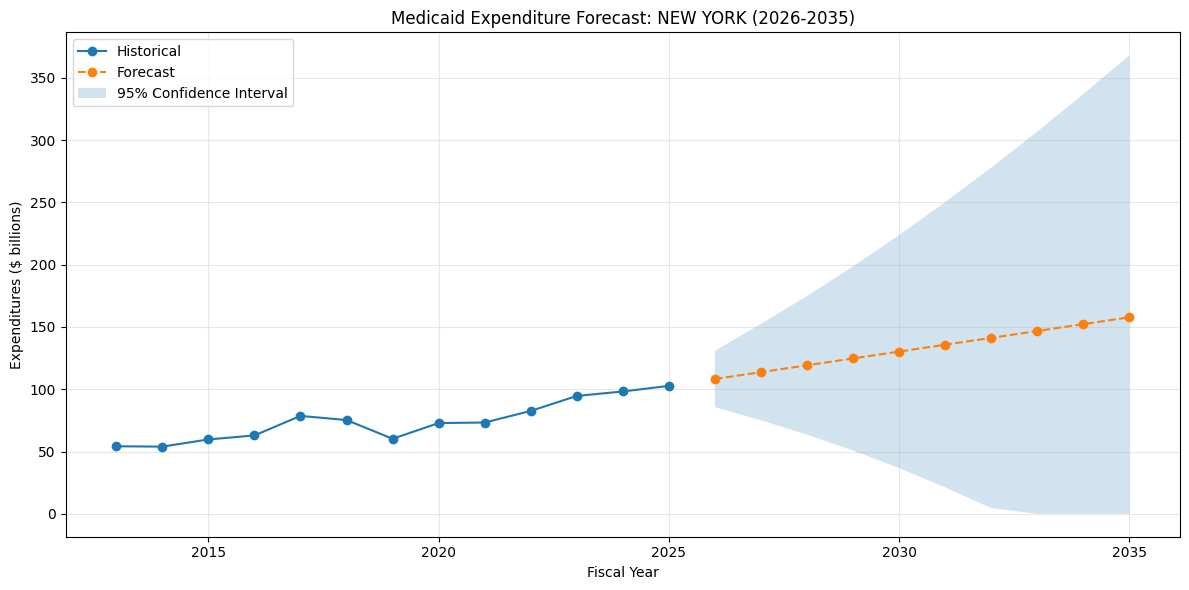

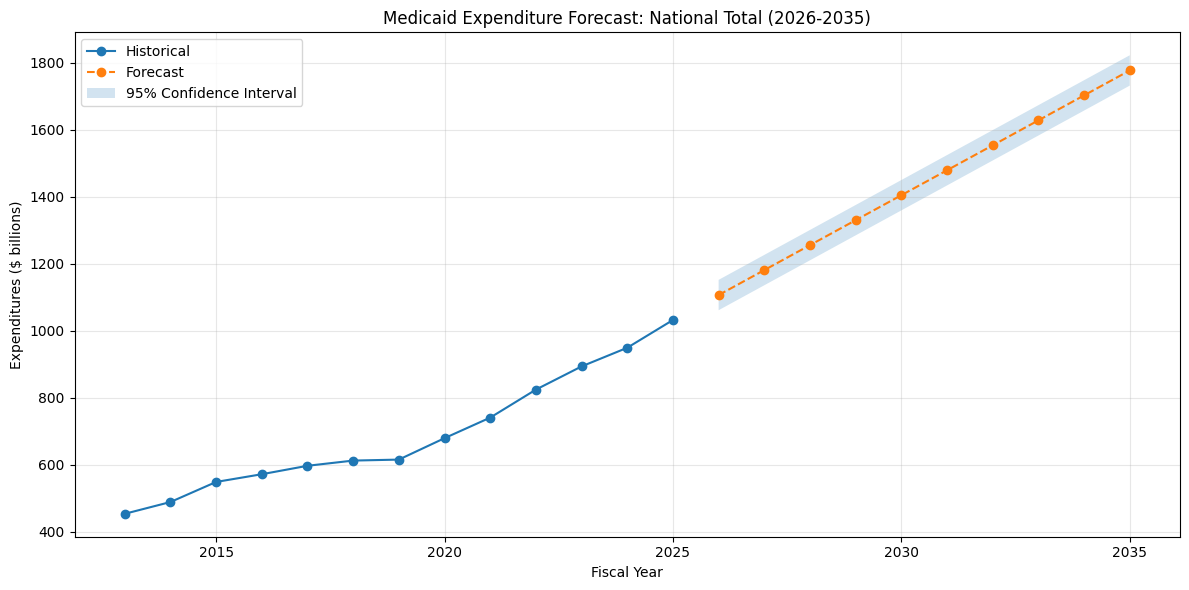

In [18]:
def plot_final_forecast(history_df, forecast_df, title, filename):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    hist = history_df.sort_values("Fiscal Year")
    fc = forecast_df.sort_values("Fiscal Year")
    
    ax.plot(hist["Fiscal Year"], dollars_billions(hist["Expenditures"]), marker="o", label="Historical")
    ax.plot(fc["Fiscal Year"], dollars_billions(fc["Projected Expenditures"]), marker="o", linestyle="--", label="Forecast")
    ax.fill_between(
        fc["Fiscal Year"].astype(float).values,
        dollars_billions(fc["Lower 95% CI"]).astype(float).values,
        dollars_billions(fc["Upper 95% CI"]).astype(float).values,
        alpha=0.2,
        label="95% Confidence Interval"
    )
    
    ax.set_title(title)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Expenditures ($ billions)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    path = CHART_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

state_forecast_chart = plot_final_forecast(
    state_df, state_forecast,
    f"Medicaid Expenditure Forecast: {STATE.upper()} ({FORECAST_START_YEAR}-{FORECAST_END_YEAR})",
    "state_final_forecast.png"
)

national_forecast_chart = plot_final_forecast(
    national_df, national_forecast,
    f"Medicaid Expenditure Forecast: National Total ({FORECAST_START_YEAR}-{FORECAST_END_YEAR})",
    "national_final_forecast.png"
)

## 12. Model comparison summary

The lowest MAPE model is selected as the final model for each forecast series.

In [19]:
model_comparison = pd.concat([state_comparison, national_comparison], ignore_index=True)
model_comparison = model_comparison.sort_values(["Entity", "MAPE"]).reset_index(drop=True)

display(model_comparison)

best_models_summary = model_comparison.loc[model_comparison.groupby("Entity")["MAPE"].idxmin()].reset_index(drop=True)
display(best_models_summary)

,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,504,840.23","29,144,348,877.18",2.74
1,NATIONAL TOTAL,"ARIMA(0, 2, 1)","30,389,179,091.86","32,801,601,321.16",3.12
2,NATIONAL TOTAL,Polynomial Regression,"47,102,709,321.58","47,978,768,884.15",4.89
3,NATIONAL TOTAL,Linear Regression,"112,706,434,239.57","116,157,169,999.72",11.64
4,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,825.52","5,871,513,803.78",5.93
5,NEW YORK,Linear Regression,"13,620,957,151.70","13,667,389,832.96",13.81
6,NEW YORK,Exponential Smoothing,"13,620,957,151.72","13,667,389,832.98",13.81
7,NEW YORK,Polynomial Regression,"19,167,953,620.50","19,373,935,444.26",19.39


,Entity,Model,MAE,RMSE,MAPE
0,NATIONAL TOTAL,Exponential Smoothing,"26,688,504,840.23","29,144,348,877.18",2.74
1,NEW YORK,"ARIMA(0, 2, 1)","5,808,949,825.52","5,871,513,803.78",5.93


## 13. Export clean forecast tables and reports

This cell exports all main deliverables into Kaggle's `/kaggle/working` folder.

In [20]:
def add_formatted_dollars(df, cols):
    out = df.copy()
    for col in cols:
        out[col + " Formatted"] = out[col].apply(lambda x: f"${x:,.0f}")
    return out

all_forecasts_export = add_formatted_dollars(
    all_forecasts,
    ["Projected Expenditures", "Lower 95% CI", "Upper 95% CI"]
)

state_forecast_export = all_forecasts_export[all_forecasts_export["Entity"] == STATE.upper()].copy()
national_forecast_export = all_forecasts_export[all_forecasts_export["Entity"] == "NATIONAL TOTAL"].copy()

state_forecast_export.to_csv(OUTPUT_DIR / "state_forecast_2026_2035.csv", index=False)
national_forecast_export.to_csv(OUTPUT_DIR / "national_forecast_2026_2035.csv", index=False)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "medicaid_projection_results.xlsx", engine="openpyxl") as writer:
    state_forecast_export.to_excel(writer, sheet_name="State Forecast", index=False)
    national_forecast_export.to_excel(writer, sheet_name="National Forecast", index=False)
    model_comparison.to_excel(writer, sheet_name="Model Comparison", index=False)
    state_eda.to_excel(writer, sheet_name="State EDA", index=False)
    national_eda.to_excel(writer, sheet_name="National EDA", index=False)

print("Exported CSV and Excel files to:", OUTPUT_DIR)

Exported CSV and Excel files to: /kaggle/working


## 14. Create HTML report

In [21]:
html_path = OUTPUT_DIR / "medicaid_projection_report.html"

html = f"""
<html>
<head>
    <title>Medicaid Expenditure Projection Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; line-height: 1.5; }}
        h1, h2 {{ color: #1f4e79; }}
        table {{ border-collapse: collapse; width: 100%; margin-bottom: 24px; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: right; }}
        th {{ background-color: #f2f2f2; }}
        td:first-child, th:first-child {{ text-align: left; }}
        img {{ max-width: 100%; height: auto; margin: 12px 0 28px 0; }}
    </style>
</head>
<body>
    <h1>Medicaid Expenditure Projection Model</h1>
    <p>This report forecasts Medicaid expenditures for <strong>{STATE.upper()}</strong> and the <strong>national total</strong> for fiscal years {FORECAST_START_YEAR}-{FORECAST_END_YEAR}.</p>
    
    <h2>Best Models</h2>
    {best_models_summary.to_html(index=False)}
    
    <h2>Model Comparison</h2>
    {model_comparison.to_html(index=False)}
    
    <h2>Forecast Table</h2>
    {all_forecasts_export[["Entity", "Fiscal Year", "Best Model", "Projected Expenditures Formatted", "Lower 95% CI Formatted", "Upper 95% CI Formatted"]].to_html(index=False)}
    
    <h2>Charts</h2>
    <h3>{STATE.upper()} Forecast</h3>
    <img src="charts/state_final_forecast.png">
    <h3>National Forecast</h3>
    <img src="charts/national_final_forecast.png">
</body>
</html>
"""

html_path.write_text(html, encoding="utf-8")
print("HTML report saved to:", html_path)

HTML report saved to: /kaggle/working/medicaid_projection_report.html


## 15. Create PDF report

This creates a simple PDF report containing the main charts and summary tables.

In [22]:
pdf_path = OUTPUT_DIR / "medicaid_projection_report.pdf"

with PdfPages(pdf_path) as pdf:
    # Title page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    title_text = f"""
    Medicaid Expenditure Projection Model

    Selected State: {STATE.upper()}
    National Total Included: Yes
    Forecast Period: {FORECAST_START_YEAR}-{FORECAST_END_YEAR}

    Models Compared:
    - Linear Regression
    - Polynomial Regression
    - Exponential Smoothing
    - ARIMA

    Evaluation Metrics:
    - MAE
    - RMSE
    - MAPE
    """
    ax.text(0.05, 0.95, title_text, va="top", fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)
    
    # Forecast charts
    for image_path in [state_forecast_chart, national_forecast_chart, state_growth_chart, national_growth_chart]:
        if image_path is not None and Path(image_path).exists():
            img = plt.imread(image_path)
            fig, ax = plt.subplots(figsize=(11, 8.5))
            ax.imshow(img)
            ax.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    
    # Model comparison table page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    table_text = model_comparison.round(2).to_string(index=False)
    ax.text(0.02, 0.98, "Model Comparison Summary\n\n" + table_text, va="top", family="monospace", fontsize=8)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)
    
    # Forecast table page
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    forecast_cols = ["Entity", "Fiscal Year", "Best Model", "Projected Expenditures Formatted", "Lower 95% CI Formatted", "Upper 95% CI Formatted"]
    forecast_text = all_forecasts_export[forecast_cols].to_string(index=False)
    ax.text(0.02, 0.98, "Forecast Table\n\n" + forecast_text, va="top", family="monospace", fontsize=7)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("PDF report saved to:", pdf_path)

PDF report saved to: /kaggle/working/medicaid_projection_report.pdf


## 16. Create README file

The assignment asks for setup instructions and usage guidance. This cell writes a README file automatically.

In [23]:
readme_text = f"""
# Medicaid Expenditure Projection Model

## Overview
This project analyzes historical Medicaid expenditure data and forecasts expenditures for {STATE.upper()} and the national total for fiscal years {FORECAST_START_YEAR}-{FORECAST_END_YEAR}.

## Tools Used
- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- statsmodels
- openpyxl

## Data
The input data consists of FY 2013-FY 2025 MFCU Statistical Chart Excel files.

## Methodology
1. Load all Excel files.
2. Clean state names and Medicaid expenditure fields.
3. Perform exploratory data analysis, including historical trends and year-over-year growth.
4. Decompose the time series into trend, seasonal-like, and residual components.
5. Train and evaluate multiple models:
   - Linear Regression
   - Polynomial Regression
   - Exponential Smoothing
   - ARIMA
6. Compare models using MAE, RMSE, and MAPE.
7. Select the best-performing model for each series.
8. Forecast Medicaid expenditures for {FORECAST_START_YEAR}-{FORECAST_END_YEAR} with 95% confidence intervals.
9. Export results to CSV, Excel, HTML, and PDF.

## Main Outputs
- state_forecast_2026_2035.csv
- national_forecast_2026_2035.csv
- model_comparison_summary.csv
- medicaid_projection_results.xlsx
- medicaid_projection_report.html
- medicaid_projection_report.pdf
- charts/ folder with visualization outputs

## How to Run on Kaggle
1. Open this notebook in Kaggle.
2. Upload or attach the dataset containing the FY Excel files.
3. Set the `STATE` variable near the top of the notebook.
4. Run all cells from top to bottom.
5. Download the output files from `/kaggle/working`.

## Notes
Confidence intervals for regression and exponential smoothing models are approximate and based on residual error. ARIMA confidence intervals are generated from the model forecast distribution when ARIMA is selected as the best model.
"""

readme_path = OUTPUT_DIR / "README.md"
readme_path.write_text(readme_text.strip(), encoding="utf-8")
print("README saved to:", readme_path)

README saved to: /kaggle/working/README.md


## 17. Final output file list

Run this final cell to confirm all exportable deliverables were created.

In [24]:
print("Exported files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

Exported files:
/kaggle/working/README.md
/kaggle/working/__notebook__.ipynb
/kaggle/working/charts/national_decomposition.png
/kaggle/working/charts/national_final_forecast.png
/kaggle/working/charts/national_historical_expenditures.png
/kaggle/working/charts/national_model_test_comparison.png
/kaggle/working/charts/national_yoy_growth.png
/kaggle/working/charts/state_decomposition.png
/kaggle/working/charts/state_final_forecast.png
/kaggle/working/charts/state_historical_expenditures.png
/kaggle/working/charts/state_model_test_comparison.png
/kaggle/working/charts/state_yoy_growth.png
/kaggle/working/medicaid_projection_report.html
/kaggle/working/medicaid_projection_report.pdf
/kaggle/working/medicaid_projection_results.xlsx
/kaggle/working/model_comparison_summary.csv
/kaggle/working/national_forecast_2026_2035.csv
/kaggle/working/state_forecast_2026_2035.csv


In [25]:
# ============================================================
# PATCH 3 — Define NY expenditure dataframe correctly
# Place BEFORE enrollment merge section
# ============================================================

ny_expenditure_source = (
    state_df[
        state_df["State"].str.upper() == "NEW YORK"
    ][["Fiscal Year", "Expenditures"]]
    .copy()
)

display(ny_expenditure_source.head())

,Fiscal Year,Expenditures
32,2013,"54,192,911,238.00"
83,2014,"53,915,930,694.00"
134,2015,"59,681,117,761.00"
185,2016,"62,909,519,309.00"
236,2017,"78,563,137,293.00"


## 18. Enrollment and Expenditure Per Person Analysis

This section expands the analysis by incorporating New York Medicaid enrollment data from the NYS Medicaid Enrollment Databook.

The purpose is to evaluate how enrollment relates to Medicaid expenditure per person.

In [26]:
# ============================================================
# Enrollment and Expenditure Per Person Analysis
# Place this section AFTER final forecast outputs/charts
# and BEFORE the conclusion/limitations section.
# ============================================================


import ipywidgets as widgets
from IPython.display import display, Markdown
from pathlib import Path

In [27]:
# ============================================================
# Load enrollment dataset
# ============================================================

# Numeric columns with commas for display
enrollment_df = pd.read_csv(enrollment_file)
numeric_cols = [
    "nyc_enrollment",
    "rest_of_state_enrollment",
    "total_enrollment"
]

for col in numeric_cols:
    enrollment_df[col] = (
        enrollment_df[col]
        .apply(lambda x: f"{x:,.0f}")
    )

display(enrollment_df.head())
display(enrollment_df.tail())

print(enrollment_df.dtypes)


,month,nyc_enrollment,rest_of_state_enrollment,total_enrollment
0,2020-05,"3,522,380","2,808,992","6,331,372"
1,2020-06,"3,575,306","2,844,811","6,420,117"
2,2020-07,"3,626,487","2,880,285","6,506,772"
3,2020-08,"3,667,320","2,913,345","6,580,665"
4,2020-09,"3,708,914","2,945,106","6,654,020"


,month,nyc_enrollment,rest_of_state_enrollment,total_enrollment
67,2025-12,"3,855,608","2,944,492","6,800,100"
68,2026-01,"3,812,792","2,927,733","6,740,525"
69,2026-02,"3,774,984","2,906,638","6,681,623"
70,2026-03,"3,626,379","2,840,523","6,466,903"
71,2026-04,"3,615,387","2,826,814","6,442,202"


month                       object
nyc_enrollment              object
rest_of_state_enrollment    object
total_enrollment            object
dtype: object


In [28]:
# ============================================================
# Prepare enrollment data
# ============================================================

# Convert month column to datetime
enrollment_df["month"] = pd.to_datetime(
    enrollment_df["month"]
)

# Extract year
enrollment_df["year"] = (
    enrollment_df["month"]
    .dt.year
)

# ============================================================
# Remove commas BEFORE numeric conversion
# ============================================================

enrollment_df["nyc_enrollment"] = (
    enrollment_df["nyc_enrollment"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

enrollment_df["rest_of_state_enrollment"] = (
    enrollment_df["rest_of_state_enrollment"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

enrollment_df["total_enrollment"] = (
    enrollment_df["total_enrollment"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

# ============================================================
# Convert enrollment columns to numeric
# ============================================================

enrollment_df["nyc_enrollment"] = pd.to_numeric(
    enrollment_df["nyc_enrollment"],
    errors="coerce"
)

enrollment_df["rest_of_state_enrollment"] = pd.to_numeric(
    enrollment_df["rest_of_state_enrollment"],
    errors="coerce"
)

enrollment_df["total_enrollment"] = pd.to_numeric(
    enrollment_df["total_enrollment"],
    errors="coerce"
)

# ============================================================
# Create formatted display dataframe
# ============================================================

formatted_enrollment_df = enrollment_df.copy()

formatted_cols = [
    "nyc_enrollment",
    "rest_of_state_enrollment",
    "total_enrollment"
]

for col in formatted_cols:

    formatted_enrollment_df[col] = (
        formatted_enrollment_df[col]
        .apply(lambda x: f"{x:,.0f}")
    )

# ============================================================
# Display formatted enrollment dataset
# ============================================================

display(formatted_enrollment_df.head())
# formatted_enrollment_df.head()

,month,nyc_enrollment,rest_of_state_enrollment,total_enrollment,year
0,2020-05-01,"3,522,380","2,808,992","6,331,372",2020
1,2020-06-01,"3,575,306","2,844,811","6,420,117",2020
2,2020-07-01,"3,626,487","2,880,285","6,506,772",2020
3,2020-08-01,"3,667,320","2,913,345","6,580,665",2020
4,2020-09-01,"3,708,914","2,945,106","6,654,020",2020


In [29]:
# ============================================================
# Create annual enrollment summary
# ============================================================

annual_enrollment = (
    enrollment_df
    .groupby("year", as_index=False)
    .agg(
        average_nyc_enrollment=("nyc_enrollment", "mean"),
        average_rest_of_state_enrollment=("rest_of_state_enrollment", "mean"),
        average_total_enrollment=("total_enrollment", "mean")
    )
)

annual_enrollment["average_nyc_enrollment"] = (
    annual_enrollment["average_nyc_enrollment"]
    .round(0)
    .astype(int)
)

annual_enrollment["average_rest_of_state_enrollment"] = (
    annual_enrollment["average_rest_of_state_enrollment"]
    .round(0)
    .astype(int)
)

annual_enrollment["average_total_enrollment"] = (
    annual_enrollment["average_total_enrollment"]
    .round(0)
    .astype(int)
)

# ============================================================
# Format ALL numeric output columns with commas
# ============================================================

formatted_annual_enrollment = annual_enrollment.copy()

numeric_cols = formatted_annual_enrollment.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:

    formatted_annual_enrollment[col] = (
        formatted_annual_enrollment[col]
        .apply(lambda x: f"{x:,.0f}")
    )

# Display formatted output
display(formatted_annual_enrollment)

# formatted_annual_enrollment

,year,average_nyc_enrollment,average_rest_of_state_enrollment,average_total_enrollment
0,2020,"3,683,186","2,926,223","6,609,409"
1,2021,"3,991,631","3,168,845","7,160,476"
2,2022,"4,233,814","3,375,873","7,609,687"
3,2023,"4,395,854","3,471,541","7,867,395"
4,2024,"4,086,787","3,074,819","7,161,607"
5,2025,"3,928,561","2,957,234","6,885,796"
6,2026,"3,707,386","2,875,427","6,582,813"


In [30]:
# ============================================================
# Interactive dropdown: enrollment summary by year
# ============================================================

available_years = sorted(annual_enrollment["year"].unique())

year_dropdown = widgets.Dropdown(
    options=available_years,
    value=max(available_years),
    description="Select Year:",
    style={"description_width": "initial"}
)

def show_enrollment(selected_year):

    row = annual_enrollment[
        annual_enrollment["year"] == selected_year
    ]

    if row.empty:

        display(
            Markdown(
                f"### No enrollment data available for {selected_year}."
            )
        )

    else:

        nyc = int(row["average_nyc_enrollment"].iloc[0])

        rest_state = int(
            row["average_rest_of_state_enrollment"].iloc[0]
        )

        total = int(row["average_total_enrollment"].iloc[0])

        display(
            Markdown(
                f"""
### New York Medicaid Enrollment Summary for {selected_year}

- **NYC Enrollment:** {nyc:,.0f} people  
- **Rest of State Enrollment:** {rest_state:,.0f} people  
- **Total NY Medicaid Enrollment:** {total:,.0f} people  
"""
            )
        )

widgets.interact(
    show_enrollment,
    selected_year=year_dropdown
);

interactive(children=(Dropdown(description='Select Year:', index=6, options=(np.int32(2020), np.int32(2021), n…

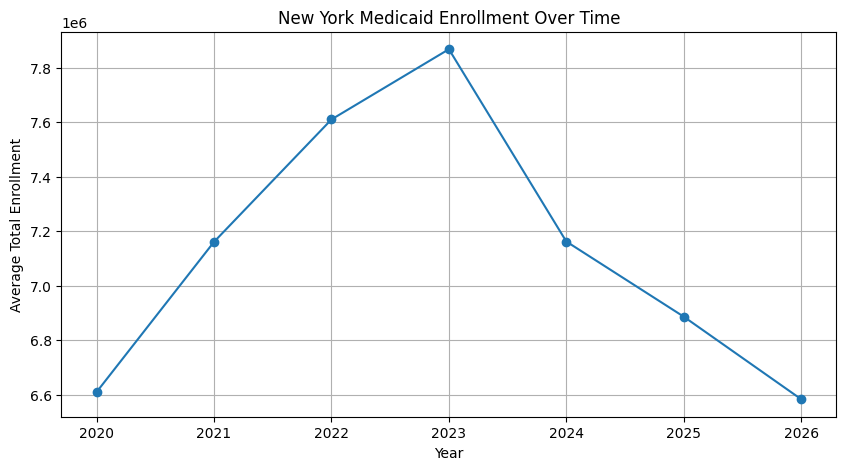

In [31]:
# ============================================================
# Visualization: Total NY Medicaid enrollment over time
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    annual_enrollment["year"],
    annual_enrollment["average_total_enrollment"],
    marker="o"
)

plt.title("New York Medicaid Enrollment Over Time")

plt.xlabel("Year")

plt.ylabel("Average Total Enrollment")

plt.grid(True)

plt.show()

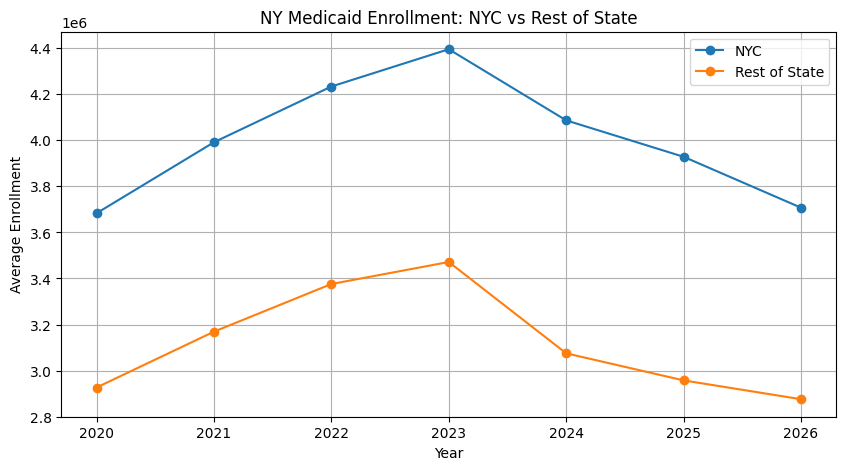

In [32]:
# ============================================================
# Visualization: NYC vs Rest of State enrollment
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    annual_enrollment["year"],
    annual_enrollment["average_nyc_enrollment"],
    marker="o",
    label="NYC"
)

plt.plot(
    annual_enrollment["year"],
    annual_enrollment["average_rest_of_state_enrollment"],
    marker="o",
    label="Rest of State"
)

plt.title("NY Medicaid Enrollment: NYC vs Rest of State")

plt.xlabel("Year")

plt.ylabel("Average Enrollment")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
# ============================================================
# Prepare New York expenditure data
# Replace ny_expenditure with your actual dataframe name
# ============================================================

display(ny_expenditure_source.head())

print(ny_expenditure_source.columns.tolist())

,Fiscal Year,Expenditures
32,2013,"54,192,911,238.00"
83,2014,"53,915,930,694.00"
134,2015,"59,681,117,761.00"
185,2016,"62,909,519,309.00"
236,2017,"78,563,137,293.00"


['Fiscal Year', 'Expenditures']


In [34]:
# ============================================================
# Standardize expenditure dataframe
# ============================================================

ny_expenditure_clean = ny_expenditure_source.copy()

ny_expenditure_clean = ny_expenditure_clean.rename(columns={
    "Fiscal Year": "year",
    "Year": "year",
    "Total Medicaid Expenditures": "expenditures",
    "Total Expenditures": "expenditures",
    "Expenditure": "expenditures",
    "Expenditures": "expenditures"
})

ny_expenditure_clean["year"] = pd.to_numeric(
    ny_expenditure_clean["year"],
    errors="coerce"
)

ny_expenditure_clean["expenditures"] = pd.to_numeric(
    ny_expenditure_clean["expenditures"],
    errors="coerce"
)

ny_expenditure_clean = ny_expenditure_clean.dropna(
    subset=["year", "expenditures"]
).copy()

ny_expenditure_clean["year"] = (
    ny_expenditure_clean["year"]
    .astype(int)
)

display(ny_expenditure_clean.head())

,year,expenditures
32,2013,"54,192,911,238.00"
83,2014,"53,915,930,694.00"
134,2015,"59,681,117,761.00"
185,2016,"62,909,519,309.00"
236,2017,"78,563,137,293.00"


In [35]:
# ============================================================
# Merge enrollment with expenditures
# ============================================================

ny_enrollment_expenditure = pd.merge(
    ny_expenditure_clean,
    annual_enrollment,
    on="year",
    how="inner"
)

ny_enrollment_expenditure["expenditure_per_person"] = (
    ny_enrollment_expenditure["expenditures"] /
    ny_enrollment_expenditure["average_total_enrollment"]
)

# ============================================================
# Create formatted display dataframe
# ============================================================

formatted_ny_enrollment_expenditure = (
    ny_enrollment_expenditure.copy()
)

# Format ALL numeric columns with commas
numeric_cols = formatted_ny_enrollment_expenditure.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:

    formatted_ny_enrollment_expenditure[col] = (
        formatted_ny_enrollment_expenditure[col]
        .apply(lambda x: f"{x:,.0f}")
    )

# Display formatted dataframe
display(formatted_ny_enrollment_expenditure)

# formatted_ny_enrollment_expenditure

,year,expenditures,average_nyc_enrollment,average_rest_of_state_enrollment,average_total_enrollment,expenditure_per_person
0,"2,020","72,816,196,684","3,683,186","2,926,223","6,609,409","11,017"
1,"2,021","73,267,974,087","3,991,631","3,168,845","7,160,476","10,232"
2,"2,022","82,564,771,704","4,233,814","3,375,873","7,609,687","10,850"
3,"2,023","94,601,679,054","4,395,854","3,471,541","7,867,395","12,025"
4,"2,024","98,177,794,119","4,086,787","3,074,819","7,161,607","13,709"
5,"2,025","102,699,327,635","3,928,561","2,957,234","6,885,796","14,915"


## Question 1: How many people are enrolled in Medicaid in New York?

To answer this question, New York Medicaid enrollment data from the NYS Medicaid Enrollment Databook was incorporated into the analysis.

The enrollment dataset was aggregated by year to calculate the average annual Medicaid enrollment across New York State.

The results show that New York Medicaid enrollment reached several million individuals annually, demonstrating the large scale and financial importance of the Medicaid program within the state.

The analysis also separated enrollment between:
- New York City enrollment,
- and Rest of State enrollment,

to better understand regional enrollment distribution across New York.

Overall, the enrollment analysis provides insight into how many individuals depend on Medicaid coverage each year and helps contextualize future expenditure trends.

## Question 2: How much is spent per enrolled person?

To answer this question, Medicaid expenditures were merged with annual enrollment totals.

Expenditure per person was calculated using the following formula:

Expenditure Per Person = Total Medicaid Expenditures / Total Medicaid Enrollment

This calculation estimates the average Medicaid spending associated with each enrolled individual during a given year.

The results suggest that Medicaid expenditures are influenced not only by the number of people enrolled, but also by changes in spending per beneficiary over time.

In some years, expenditure per person continued increasing even when enrollment growth stabilized or declined, suggesting that rising healthcare costs, utilization rates, or operational expenses may also contribute to overall expenditure growth.

This analysis helps provide a deeper understanding of whether Medicaid spending increases are primarily driven by:
- increasing enrollment,
- rising healthcare costs per enrollee,
- or a combination of both factors.

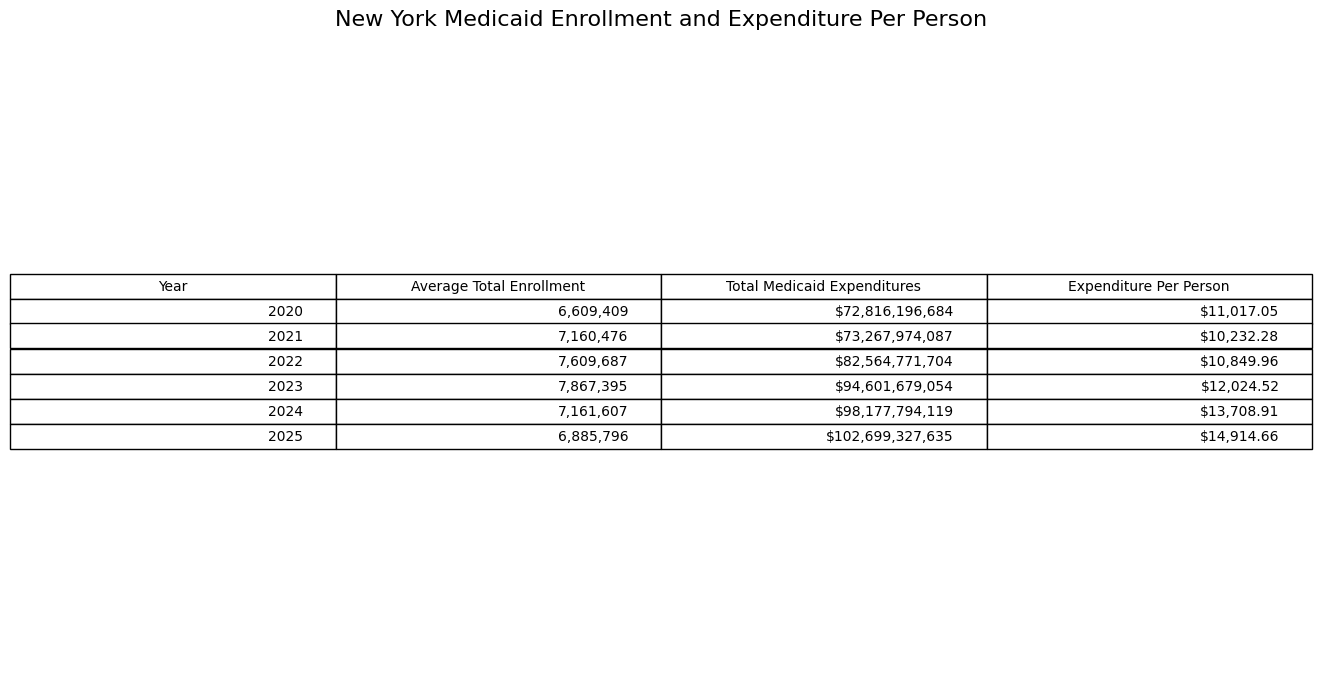

In [36]:
# ============================================================
# Tabular Visualization:
# Enrollment and Expenditure Per Person
# ============================================================

# Create formatted table for visualization
table_df = ny_enrollment_expenditure.copy()

# Format columns for readability
table_df["average_total_enrollment"] = (
    table_df["average_total_enrollment"]
    .apply(lambda x: f"{x:,.0f}")
)

table_df["expenditures"] = (
    table_df["expenditures"]
    .apply(lambda x: f"${x:,.0f}")
)

table_df["expenditure_per_person"] = (
    table_df["expenditure_per_person"]
    .apply(lambda x: f"${x:,.2f}")
)

# Select columns for display
table_df = table_df[[
    "year",
    "average_total_enrollment",
    "expenditures",
    "expenditure_per_person"
]]

# Rename columns for presentation
table_df.columns = [
    "Year",
    "Average Total Enrollment",
    "Total Medicaid Expenditures",
    "Expenditure Per Person"
]

# ============================================================
# Plot table using matplotlib
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title(
    "New York Medicaid Enrollment and Expenditure Per Person",
    fontsize=16,
    pad=20
)

plt.show()

In [37]:
# ============================================================
# Interactive dropdown:
# enrollment + expenditure per person
# ============================================================

available_merged_years = sorted(
    ny_enrollment_expenditure["year"].unique()
)

year_dropdown_2 = widgets.Dropdown(
    options=available_merged_years,
    value=max(available_merged_years),
    description="Select Year:",
    style={"description_width": "initial"}
)

def show_enrollment_and_spending(selected_year):

    row = ny_enrollment_expenditure[
        ny_enrollment_expenditure["year"] == selected_year
    ]

    if row.empty:

        display(
            Markdown(
                f"### No data available for {selected_year}."
            )
        )

    else:

        enrollment_value = int(
            row["average_total_enrollment"].iloc[0]
        )

        expenditure_value = row["expenditures"].iloc[0]

        per_person_value = row[
            "expenditure_per_person"
        ].iloc[0]

        display(
            Markdown(
                f"""
### New York Medicaid Summary for {selected_year}

- **Average Total Enrollment:** {enrollment_value:,.0f} people  
- **Total Medicaid Expenditures:** ${expenditure_value:,.0f}  
- **Expenditure Per Person:** ${per_person_value:,.2f}
"""
            )
        )

widgets.interact(
    show_enrollment_and_spending,
    selected_year=year_dropdown_2
);

interactive(children=(Dropdown(description='Select Year:', index=5, options=(np.int64(2020), np.int64(2021), n…

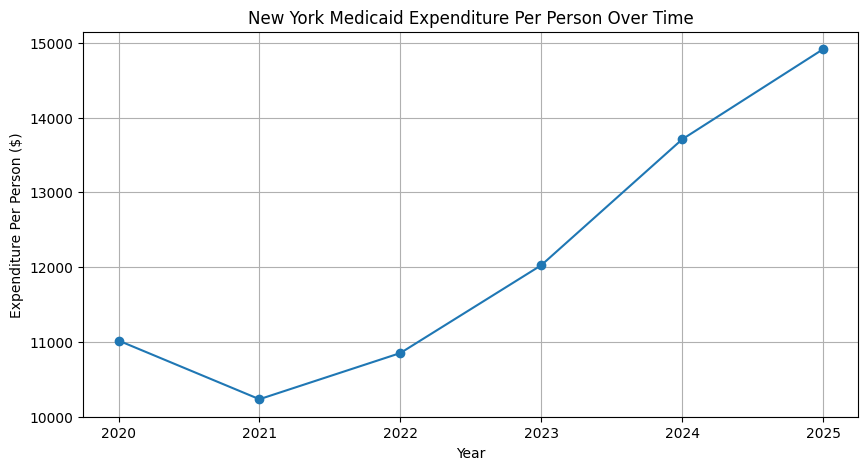

In [38]:
# ============================================================
# Visualization:
# expenditure per person over time
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    ny_enrollment_expenditure["year"],
    ny_enrollment_expenditure["expenditure_per_person"],
    marker="o"
)

plt.title(
    "New York Medicaid Expenditure Per Person Over Time"
)

plt.xlabel("Year")

plt.ylabel("Expenditure Per Person ($)")

plt.grid(True)

plt.show()

## Q3 - Interpretation: Enrollment vs Expenditure Per Person

The visualization suggests that there may be a relationship between Medicaid enrollment levels and expenditure per person over time.

Periods with higher enrollment levels generally coincide with changes in expenditure per person, indicating that Medicaid spending behavior may be influenced by both population enrollment and healthcare costs per beneficiary.

The chart also suggests that increases in total expenditures are not explained solely by enrollment growth. In some years, expenditure per person continues to rise even when enrollment begins to stabilize or decline.

This may indicate that factors such as rising healthcare costs, service utilization, inflation, or operational expenses could also contribute to Medicaid expenditure growth.

Overall, the analysis suggests that Medicaid expenditure trends are likely influenced by a combination of:
- enrollment growth,
- healthcare cost increases,
- and spending per enrolled individual.

This relationship highlights the importance of monitoring both enrollment levels and per-person expenditures when evaluating long-term Medicaid financial sustainability and healthcare planning decisions.

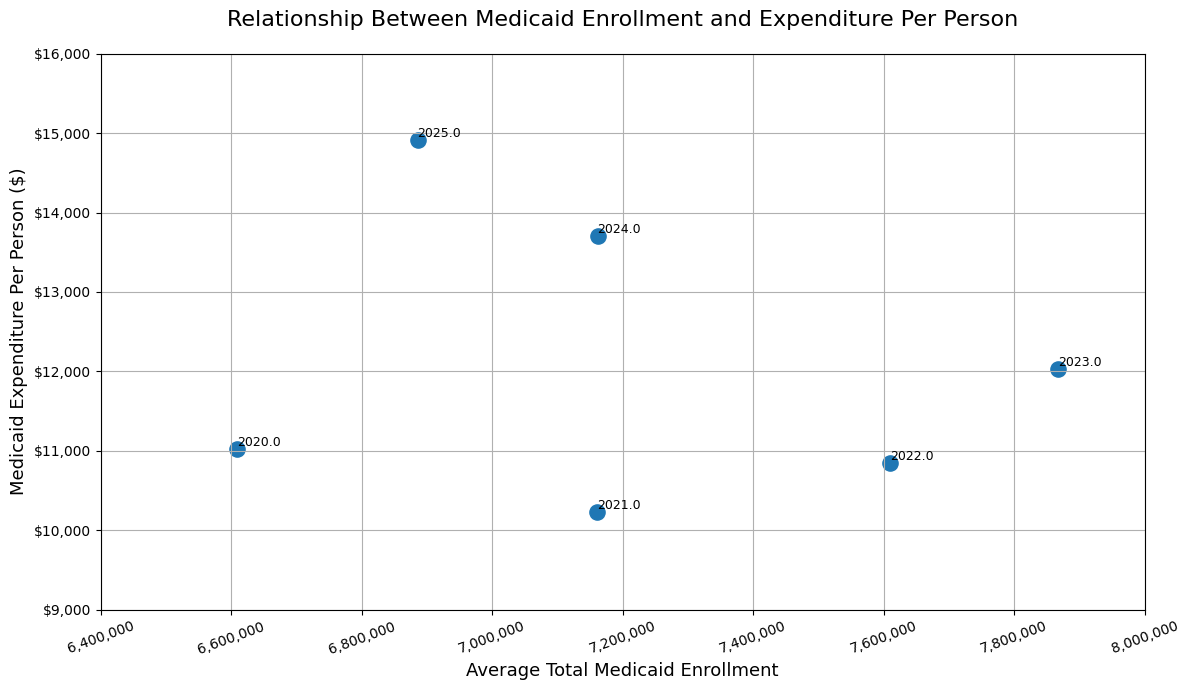

In [39]:
# ============================================================
# Enrollment vs Expenditure Per Person
# ============================================================

plt.figure(figsize=(12, 7))

# Scatter plot
plt.scatter(
    ny_enrollment_expenditure["average_total_enrollment"],
    ny_enrollment_expenditure["expenditure_per_person"],
    s=120
)

# Add year labels to each point
for _, row in ny_enrollment_expenditure.iterrows():

    plt.text(
        row["average_total_enrollment"],
        row["expenditure_per_person"],
        str(row["year"]),
        fontsize=9,
        ha="left",
        va="bottom"
    )

# Format x-axis with commas
plt.ticklabel_format(style='plain', axis='x')

# Custom readable x-axis labels
x_ticks = plt.xticks()[0]

plt.xticks(
    x_ticks,
    [f"{int(x):,}" for x in x_ticks],
    rotation=20
)

# Custom readable y-axis labels
y_ticks = plt.yticks()[0]

plt.yticks(
    y_ticks,
    [f"${int(y):,}" for y in y_ticks]
)

# Titles and labels
plt.title(
    "Relationship Between Medicaid Enrollment and Expenditure Per Person",
    fontsize=16,
    pad=20
)

plt.xlabel(
    "Average Total Medicaid Enrollment",
    fontsize=13
)

plt.ylabel(
    "Medicaid Expenditure Per Person ($)",
    fontsize=13
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [40]:
# ============================================================
# Export enhanced enrollment results
# ============================================================

annual_enrollment.to_csv(
    "ny_annual_medicaid_enrollment.csv",
    index=False
)

ny_enrollment_expenditure.to_csv(
    "ny_enrollment_expenditure_per_person.csv",
    index=False
)

print("Exported files:")

print("- ny_annual_medicaid_enrollment.csv")

print("- ny_enrollment_expenditure_per_person.csv")

Exported files:
- ny_annual_medicaid_enrollment.csv
- ny_enrollment_expenditure_per_person.csv


## Enrollment Analysis Interpretation

This section helps determine whether Medicaid expenditure growth may be related to enrollment growth, higher spending per enrolled person, or both.

If enrollment increases while expenditure per person remains stable, total expenditure growth may be mostly enrollment-driven.

If enrollment remains stable or decreases while expenditure per person increases, then rising costs per enrollee may be a stronger driver of Medicaid spending growth.

## Conclusion 

Overall, this project developed a complete analytical workflow to evaluate historical Medicaid expenditures, generate future expenditure projections, and analyze Medicaid enrollment trends within New York State.

The project began by exploring and preparing historical Medicaid expenditure data obtained from the Medicaid Fraud Control Unit Statistical Reports. The analysis included data cleaning, validation, exploratory analysis, historical trend visualization, and forecasting preparation.

Historical expenditure analysis showed that Medicaid expenditures have generally increased over time, suggesting growing healthcare-related financial demands and increasing Medicaid spending across New York State.

To estimate future expenditure behavior, multiple forecasting models were evaluated, including:

Linear Regression,
Polynomial Regression,
Exponential Smoothing,
and ARIMA.

The models were compared using forecasting evaluation metrics such as:

MAE,
RMSE,
and MAPE.

The forecasting analysis suggested that Medicaid expenditures may continue increasing if historical trends persist. These projections highlight the importance of long-term healthcare planning, budgeting, and operational preparedness within Medicaid systems.

To further expand the analysis, New York Medicaid enrollment data from the NYS Medicaid Enrollment Databook was incorporated into the project.

This additional dataset helped answer three important business questions:

How many people are enrolled in Medicaid in New York?
How much is spent per enrolled person?
Is there a relationship between Medicaid enrollment and expenditure per person?

The enrollment analysis demonstrated that several million individuals are enrolled in Medicaid across New York State annually, emphasizing the scale and operational importance of the Medicaid program.

The project then calculated expenditure per enrolled individual by combining annual Medicaid expenditure totals with annual enrollment levels.

This extended analysis suggested that Medicaid expenditure growth may be influenced not only by enrollment growth, but also by increasing healthcare spending per beneficiary over time.

The relationship analysis between enrollment and expenditure per person suggested that there may be a meaningful relationship between Medicaid enrollment levels and spending intensity per enrollee.

The analysis showed that increases in Medicaid expenditures are not explained solely by enrollment growth. In some periods, expenditure per person continued increasing even when enrollment growth stabilized or declined.

This suggests that factors such as:

rising healthcare costs,
inflation,
healthcare utilization,
operational expenses,
and service demand may also contribute significantly to long-term Medicaid expenditure growth.

From a business and healthcare perspective, these findings highlight the importance of:

proactive financial planning,
resource allocation,
healthcare cost management,
and long-term Medicaid sustainability.

If Medicaid expenditures continue increasing while spending per person also rises, healthcare systems may face growing operational and financial pressure over time.

Forecasting and enrollment analysis can help organizations prepare proactively for future healthcare spending demands rather than reacting after financial strain already exists.

At the same time, several limitations should be considered.

Forecasting accuracy depends heavily on the quality and consistency of historical data, and future expenditures may be influenced by external factors such as:

policy changes,
economic conditions,
inflation,
demographic changes,
public health events,
and healthcare utilization trends.

Therefore, the projections and enrollment analyses should be interpreted as analytical estimates designed to support strategic healthcare decision making rather than exact future predictions.

Overall, this project demonstrates a complete healthcare analytics workflow involving:

data preparation,
exploratory analysis,
forecasting,
model evaluation,
enrollment analysis,
expenditure-per-person analysis,
relationship analysis,
visualization,
and business interpretation.

One of the most important takeaways from this project was understanding the importance of combining technical analysis with business interpretation to better support healthcare planning, operational decision making, and long-term Medicaid sustainability discussions.